#  ADDITIONAL EXERCISE2 

# TITLE: - Image Classification (Animal Detection)
# Problem Statement:
# Classify images into categories like dog, cat, etc.

## Importing Libraries

In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

from tensorflow import keras
from keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image_dataset_from_directory

import os
import matplotlib.image as mpimg

## Importing Dataset 

### The ZipFile module extracts dataset files from the zip archive.
### Extracted data is stored in the 'dog-vs-cat-classification' folder.

In [2]:
from zipfile import ZipFile
data_path = 'archive.zip'
with ZipFile(r'C:\Users\koyaj\Downloads\archive.zip', 'r') as zip:
    
    print('The data set has been extracted.')

The data set has been extracted.


In [3]:
import os

print(os.path.exists(r'C:\Users\koyaj\Downloads\dataset\test\cats'))

True


## Visualizating the Data

### fig = plt.gcf() gets the current figure.
### fig.set_size_inches(16, 16) sets the figure size.
### cat_dir and dog_dir define paths to the cat and dog image directories.
### cat_names and dog_names list the image files in each directory.
### cat_images and dog_images select images based on pic_index.
### plt.subplot(4, 4, i+1) creates a 4x4 grid for images.
### sp.axis('Off') hides the axis.
### mpimg.imread(img_path) reads each image and plt.imshow(img) displays it.
### plt.show() shows the grid of images.

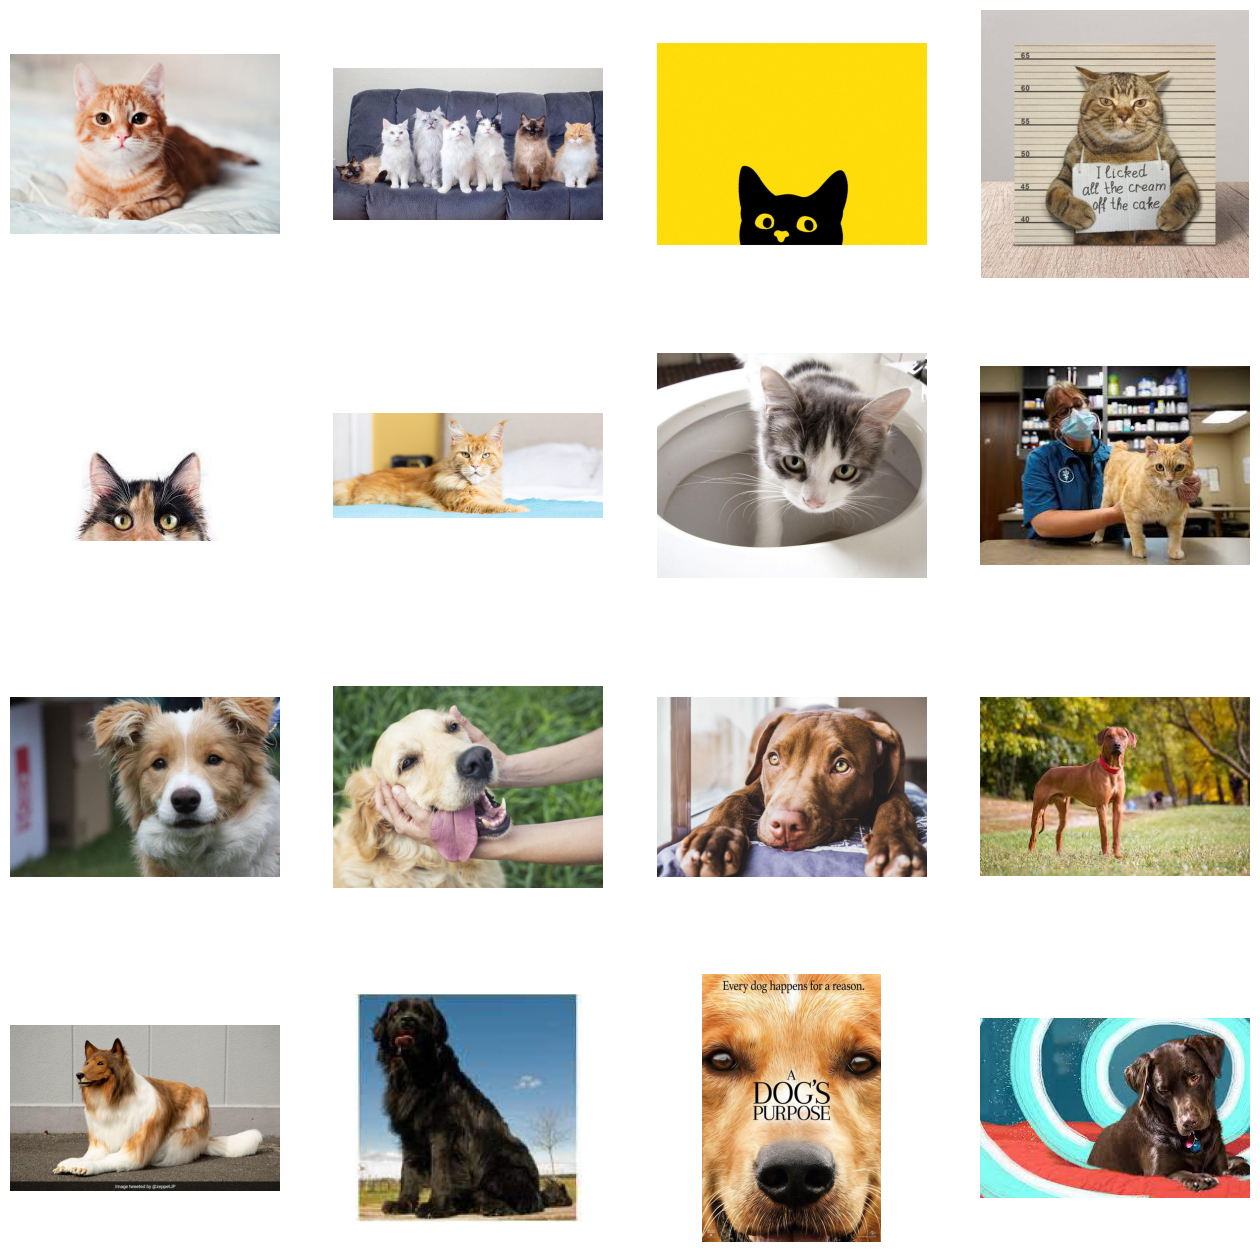

In [4]:
fig = plt.gcf()
fig.set_size_inches(16, 16)

cat_dir = r'C:\Users\koyaj\Downloads\dataset\test\cats'
dog_dir = r'C:\Users\koyaj\Downloads\dataset\test\dogs'
cat_names = os.listdir(cat_dir)
dog_names = os.listdir(dog_dir)

pic_index = 20

cat_images = [os.path.join(cat_dir, fname)
              for fname in cat_names[pic_index-8:pic_index]]
dog_images = [os.path.join(dog_dir, fname)
              for fname in dog_names[pic_index-8:pic_index]]

for i, img_path in enumerate(cat_images + dog_images):
    sp = plt.subplot(4, 4, i+1)
    sp.axis('Off')

    img = mpimg.imread(img_path)
    plt.imshow(img)

plt.show()

## Splitting Dataset
### We split the dataset into training and validation sets.

### image_dataset_from_directory: is used for data augmentation and scaling images.
### The dataset is split into 90% training and 10% validation.
### target_size=(200, 200): Resizes images to 200x200 pixels.
### batch_size=32: Defines the number of images per batch.

In [5]:
base_dir = r'C:\Users\koyaj\Downloads\dataset\test'

train_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='training',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)
test_datagen = image_dataset_from_directory(base_dir,
                                                  image_size=(200,200),
                                                  subset='validation',
                                                  seed = 1,
                                                 validation_split=0.1,
                                                  batch_size= 32)

Found 140 files belonging to 2 classes.
Using 126 files for training.
Found 140 files belonging to 2 classes.
Using 14 files for validation.


## Model Architecture
### The model will contain the following Layers:

### Conv2D layers: extract image features like edges, shapes and textures.
### MaxPooling2D: reduces image dimensions while retaining important information.
### BatchNormalization: helps stabilize training and speed up convergence.
### Dropout layers: prevent overfitting.
### sigmoid activation: outputs a binary classification as Cat or Dog.

In [6]:
model = tf.keras.models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(200, 200, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.1),
    layers.BatchNormalization(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,902,529 (14.89 MB)

 Trainable params: 3,899,457 (14.88 MB)

 Non-trainable params: 3,072 (12.00 KB)

## Model Compilation and Training
### Now we will compile and train our model. We used Binary Crossentropy Loss Function for binary classification problems with Adam optimizer.

### model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']) compiles the model with binary cross-entropy loss, Adam optimizer and accuracy as the metric.
### history = model.fit(train_datagen, epochs=10, validation_data=test_datagen) trains the model for 10 epochs using the training data and validates it using the test data.

In [7]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(train_datagen,
          epochs=10,
          validation_data=test_datagen)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5079 - loss: 0.9308 - val_accuracy: 0.3571 - val_loss: 18.7389
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 639ms/step - accuracy: 0.6825 - loss: 0.6535 - val_accuracy: 0.3571 - val_loss: 8.3207
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 663ms/step - accuracy: 0.8016 - loss: 0.4315 - val_accuracy: 0.5000 - val_loss: 1.3480
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 574ms/step - accuracy: 0.8016 - loss: 0.3967 - val_accuracy: 0.3571 - val_loss: 9.3968
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 591ms/step - accuracy: 0.8492 - loss: 0.3368 - val_accuracy: 0.3571 - val_loss: 4.7061
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 673ms/step - accuracy: 0.8730 - loss: 0.3102 - val_accuracy: 0.3571 - val_loss: 5.7198
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 592ms/step - accuracy: 0.8810 - loss: 0.2497 - val_accuracy: 0.5000 - val_loss: 0.8934
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 622ms/step - accuracy: 0.9365 - loss: 0.2114 - val_accuracy: 0.6429 - val_loss: 

## Model Evaluation
### Let’s visualize the training and validation accuracy with each epoch.

### history_df = pd.DataFrame(history.history) converts the training history into a DataFrame.
### history_df.loc[:, ['loss', 'val_loss']].plot() plots the training and validation loss.
### history_df.loc[:, ['accuracy', 'val_accuracy']].plot() plots the training and validation accuracy.

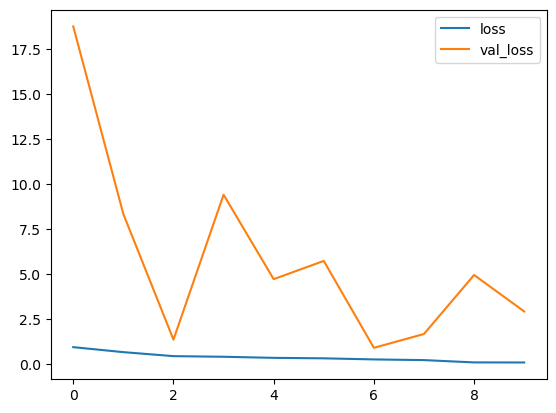

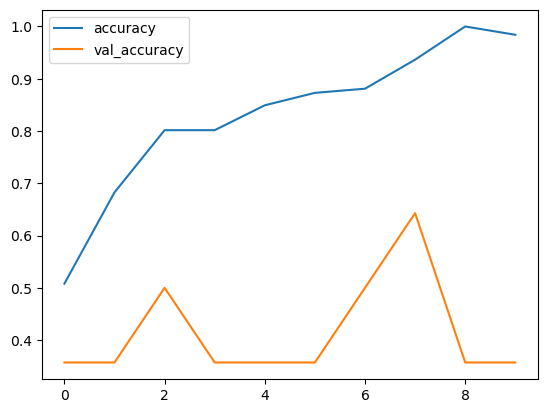

In [8]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()
history_df.loc[:, ['accuracy', 'val_accuracy']].plot()
plt.show()

## Model Testing and Prediction


### img = image.load_img(image_path, target_size=(200, 200)) loads the image and resizes it to 200x200 pixels.
### plt.imshow(img) displays the image.
### img = image.img_to_array(img) converts the image to a NumPy array.
### img = np.expand_dims(img, axis=0) adds an extra dimension for batch processing.
### result = model.predict(img) makes a prediction using the model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
Dog
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Dog


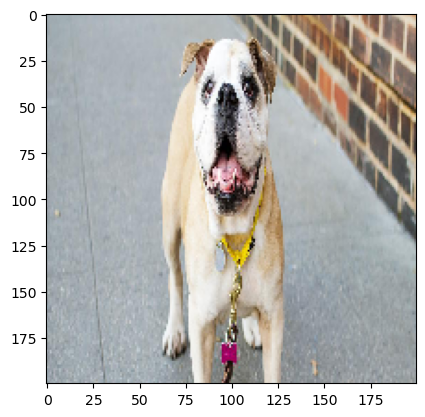

In [9]:
# Import the required modules
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(200, 200))
    plt.imshow(img)
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)

    result = model.predict(img)
    print("Dog" if result <= 0.5 else "Cat")
    
predict_image(r'C:\Users\koyaj\Downloads\dataset\test\cats\cat_60.jpg')
predict_image(r'C:\Users\koyaj\Downloads\dataset\train\dogs\dog_62.jpg')

## Deployment

## We use !pip install streamlit to install the Streamlit library so we can build and run web apps from Python code.

In [10]:
!pip install streamlit

## We use model.save("animal_model.h5") to store the trained model so it can be reused later without retraining.

In [11]:
model.save("animal_model.h5")


In [21]:
%%writefile app.py
# Saves this code into a file named app.py.
import streamlit as st # Imports the Streamlit library to create the web app.
from tensorflow.keras.models import load_model # from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image # Imports image processing utilities.
import numpy as np # Imports NumPy for numerical operations.

model = load_model("animal_model.h5") # Loads the saved trained model.

st.title("Animal Image Classifier 🐶🐱") # Displays the title on the web page.

uploaded_file = st.file_uploader("Upload an image", type=["jpg","png","jpeg"]) # Creates a file upload option for users.

if uploaded_file is not None: # Checks whether a file is uploaded.
    img = image.load_img(uploaded_file, target_size=(200,200)) # Loads and resizes the uploaded imag
    st.image(img, caption="Uploaded Image", use_column_width=True) # Displays the uploaded image.

    img = image.img_to_array(img) # Converts image into array format.
    img = np.expand_dims(img, axis=0) # Adds batch dimension for prediction.

    result = model.predict(img) # Predicts the class using the model.

    if result <= 0.5: # Checks if prediction corresponds to Dog.
        st.write("Prediction: Dog 🐶") # Displays Dog as output.
    else: # If not Dog, then go to else condition.
        st.write("Prediction: Cat 🐱") # Displays Cat as output.

Overwriting app.py
